In [6]:
import pandas as pd
import numpy as np
import FinanceDataReader as fdr
from sklearn.preprocessing import MinMaxScaler

print("데이터 전처리를 시작합니다..")

# 1. 삼성전자(005930) 주가 데이터 불러오기 (근 5년치)
df = fdr.DataReader('005930', '2019-01-01')
data = df[['Close']].values # 종가 데이터만 모아서 Numpy 배열로 변환

# 2. 데이터 정규화 (0~1 사이로 압축)
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# 3. 윈도우 슬라이딩 알고리즘 (과거 20일치 데이터로 다음 날 예측)
window_size = 20
x = []
y = []

for i in range(window_size, len(scaled_data)):
    x.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

# 4. 딥러닝 모델이 선호하는 형태(Numpy 배열)로 변환
x, y = np.array(x), np.array(y)

# LSTM 모델에 넣기 위해 3차원 배열로 형태 변경: (데이터 개수, 20일, 1개의 특징)

x = np.reshape(x, (x.shape[0], x.shape[1], 1))

print("데이터 전처리 완료")
print(f"input의 크기: {x.shape}")
print(f"output의 크기: {y.shape}")

데이터 전처리를 시작합니다..
데이터 전처리 완료
input의 크기: (1740, 20, 1)
output의 크기: (1740,)


In [9]:
import torch
import torch.nn as nn

# 1. Numpy 배열을 파이토치 텐서(Tensor)로 변환
x_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # 정답지도 (1740, 1) 형태로

# 2. LSTM 모델 뼈대 클래스 설계
class StockPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layzers=2):
        super(StockPredictor, self).__init__()
        # 핵심 부품 : LSTM 레이어
        self.lstm = nn.LSTM(input_size, hidden_size, num_layzers, batch_first=True)
        # 마지막 부품 : 결과를 1개의 숫자(주가)로 뽑아내는 선형 계층
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        # x가 LSTM을 통과함
        out, _ = self.lstm(x)
        # 20일치 흐름을 다 본 '마지막 날'의 결과값만 뽑아서 선형 계층으로 보냄
        out = self.fc(out[:, -1, :])
        return out

# 3. 모델, 손실 함수, 최적화 도구 세팅
model = StockPredictor()
criterion = nn.MSELoss() # 주가 예측의 국룰: 평균 제곱 오차(MSE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # Adam 최적화(AI의 학습 방향타)

# 4. 본격적인 학습 시작!
epochs = 100
print("모델 학습을 시작합니다. ")

for epoch in range(epochs):
    # 기울기 초기화
    optimizer.zero_grad()
    
    # 모델에 문제지 넣고 예측해보기 (Forward)
    outputs = model(x_tensor)
    
    # 실제 정답과 비교해서 얼마나 틀렸는지 오차(Loss) 계산
    loss = criterion(outputs, y_tensor)
    
    # 오차를 줄이기 위해 AI 뇌세포(가중치) 업데이트 (Backward)
    loss.backward()
    optimizer.step()
    
    # 10epoch마다 진행 상황 출력
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}, Loss: {loss.item():.4f}]")
        
print("학습 완료")

모델 학습을 시작합니다. 
Epoch [10/100, Loss: 0.0117]
Epoch [20/100, Loss: 0.0108]
Epoch [30/100, Loss: 0.0041]
Epoch [40/100, Loss: 0.0008]
Epoch [50/100, Loss: 0.0006]
Epoch [60/100, Loss: 0.0003]
Epoch [70/100, Loss: 0.0002]
Epoch [80/100, Loss: 0.0002]
Epoch [90/100, Loss: 0.0002]
Epoch [100/100, Loss: 0.0002]
학습 완료


예측 결과 그래프로 그리기


c:\Users\sehol\Desktop\이세호\04_Coding\00_myProject\FinTech_AI_Project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sehol\Desktop\이세호\04_Coding\00_myProject\FinTech_AI_Project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sehol\Desktop\이세호\04_Coding\00_myProject\FinTech_AI_Project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49340 (\N{HANGUL SYLLABLE SAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sehol\Desktop\이세호\04_Coding\00_myProject\FinTech_AI_Project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

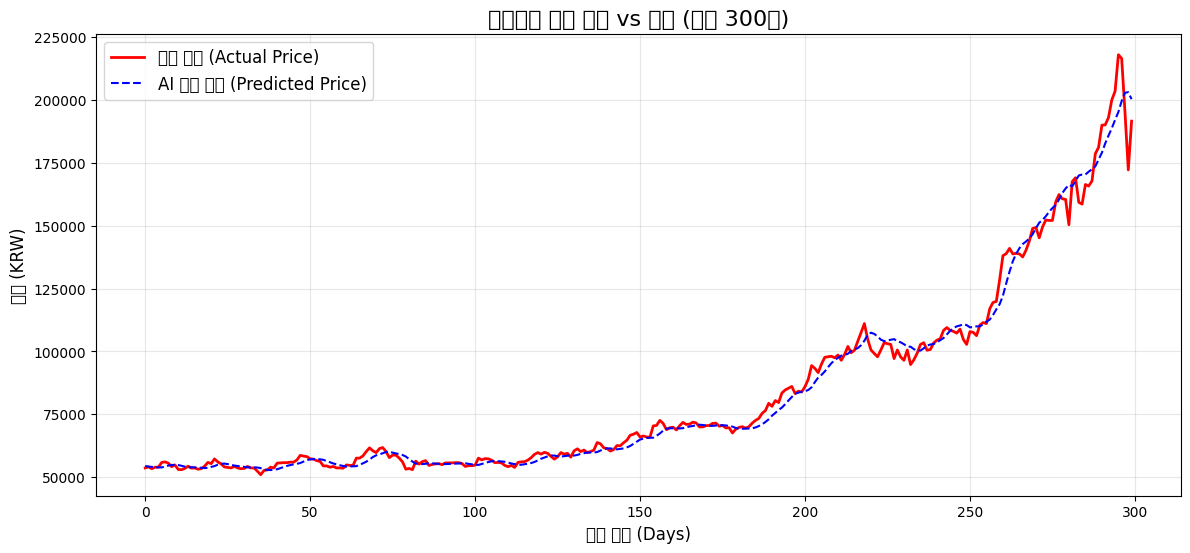

In [10]:
import matplotlib.pyplot as plt

print("예측 결과 그래프로 그리기")

# 1. 모델을 '평가모드'로 전환
model.eval()

# 2. 우리가 만든 문제지를 모델에 넣고 예측값 뽑아내기
# with torch.no_grad()는 기울기 계산하지 말라는 뜻 (속도 향상)
with torch.no_grad():
    predicted_scaled = model(x_tensor).numpy()
    
# 3. 마법의 역정규화 (0~1 값을 다시 80,000원 같은 실제 주가로 복구!)
predicted_price = scaler.inverse_transform(predicted_scaled)

# 정답지도 비교를 위해 원래 주가로 복구
actual_price = scaler.inverse_transform(y.reshape(-1, 1))

# 4. 실제 주가(빨) vs 예측 주가(파) 그래프 그리기
plt.figure(figsize=(14,6))

# 데이터가 너무 많으면 그래프가 뭉개지니까 최근 300일 치 흐름만 확대해서
plt.plot(actual_price[-300:], color='red', label='실제 주가 (Actual Price)', linewidth=2)
plt.plot(predicted_price[-300:], color='blue', label='AI 예측 주가 (Predicted Price)', linestyle='dashed')

plt.title('삼성전자 주가 실제 vs 예측 (최근 300일)', fontsize=16)
plt.xlabel('시간 흐름 (Days)', fontsize=12)
plt.ylabel('주가 (KRW)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()